In [7]:
from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales (1).csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Future Sales:
[47421229.39108934 47425504.52860058 47429779.66611183 47434054.80362307
 47438329.94113432 47442605.07864556 47446880.2161568  47451155.35366805
 47455430.49117929 47459705.62869054 47463980.76620179 47468255.90371303
 47472531.04122427 47476806.17873552 47481081.31624676 47485356.45375801
 47489631.59126925 47493906.72878049 47498181.86629174 47502457.00380298
 47506732.14131423 47511007.27882548 47515282.41633672 47519557.55384796
 47523832.69135921 47528107.82887045 47532382.9663817  47536658.10389294
 47540933.24140419 47545208.37891543]


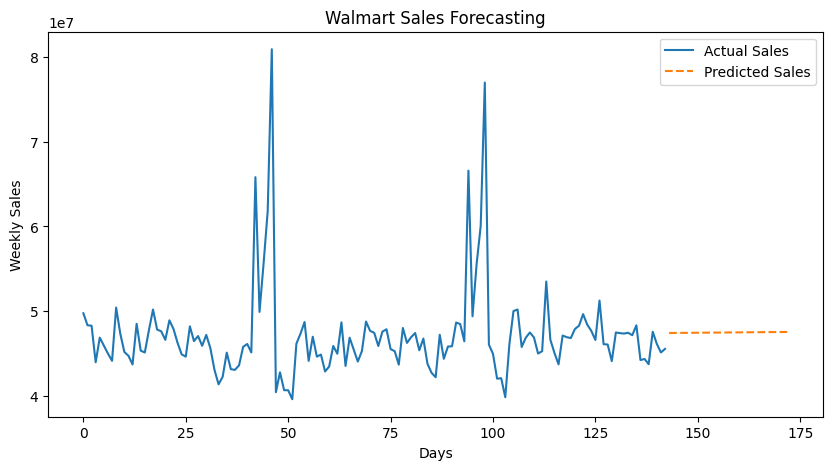

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import os

# Load dataset
df = pd.read_csv("sales.csv")

# Select needed columns
df = df[['Date', 'Weekly_Sales']]

# Convert date
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

# Sort data
df = df.sort_values('Date')

# Group weekly sales by date
sales_data = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Create day numbers
sales_data['Day_Number'] = range(len(sales_data))

# Input and Output
X = sales_data[['Day_Number']]
y = sales_data['Weekly_Sales']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 30 days
future_days = np.arange(
    len(sales_data),
    len(sales_data)+30
).reshape(-1,1)

future_sales = model.predict(future_days)

# Print predictions
print("Predicted Future Sales:")
print(future_sales)

# Plot graph
plt.figure(figsize=(10,5))

# Actual Sales
plt.plot(
    sales_data['Day_Number'],
    sales_data['Weekly_Sales'],
    label='Actual Sales'
)

# Forecast
plt.plot(
    future_days,
    future_sales,
    linestyle='--',
    label='Predicted Sales'
)

plt.xlabel("Days")
plt.ylabel("Weekly Sales")
plt.title("Walmart Sales Forecasting")
plt.legend()

# Create the directory if it doesn't exist
os.makedirs('FUTURE_ML_01/images/', exist_ok=True)

# Save image
plt.savefig("FUTURE_ML_01/images/sales_trend.png")

# Show graph
plt.show()

In [10]:
with open("FUTURE_ML_01/requirements.txt", "w") as f:
    f.write(
        "pandas\n"
        "numpy\n"
        "matplotlib\n"
        "scikit-learn\n"
    )

In [11]:
readme_text = """
# Sales & Demand Forecasting using Walmart Dataset

## Project Overview
This project predicts future Walmart sales using Machine Learning.

## Dataset
Walmart Sales Dataset

## Algorithm Used
Linear Regression

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Output
- Sales forecasting graph
- Future sales prediction

## Project Structure
FUTURE_ML_01/
│
├── data/
├── images/
│   └── sales_trend.png
├── requirements.txt
└── README.md
"""

with open("FUTURE_ML_01/README.md", "w") as f:
    f.write(readme_text)